In [120]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [121]:
plt.style.use('dark_background')
print(tf.__version__)

2.20.0


In [122]:
fashion_mnist = keras.datasets.fashion_mnist
# funkcija load_data vraca dva uredjena para (trening i test), kod kojih je prvi element niz slika, a drugi je niz labela (katergorija kojoj slike pripadaju)
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
# ovo su zapravo numpy nizovi

In [123]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [124]:
# analiza podataka
train_images.shape

(60000, 28, 28)

In [125]:
train_labels.shape

(60000,)

In [126]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [127]:
test_images.shape

(10000, 28, 28)

In [128]:
test_labels.shape

(10000,)

In [129]:
# pretprocesiranje

# skaliramo piksele na opseg [0, 1]
train_images = train_images / 255.0
test_images = test_images / 255.0

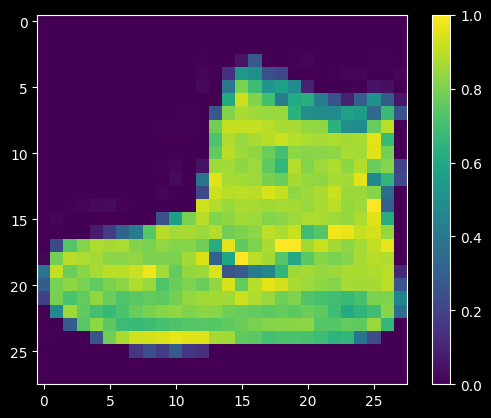

In [130]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

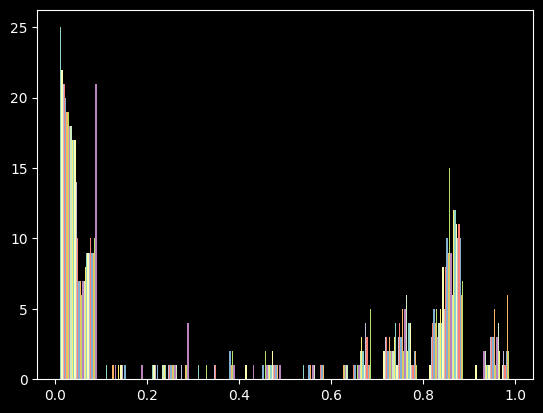

In [131]:
_ = plt.hist(train_images[0])

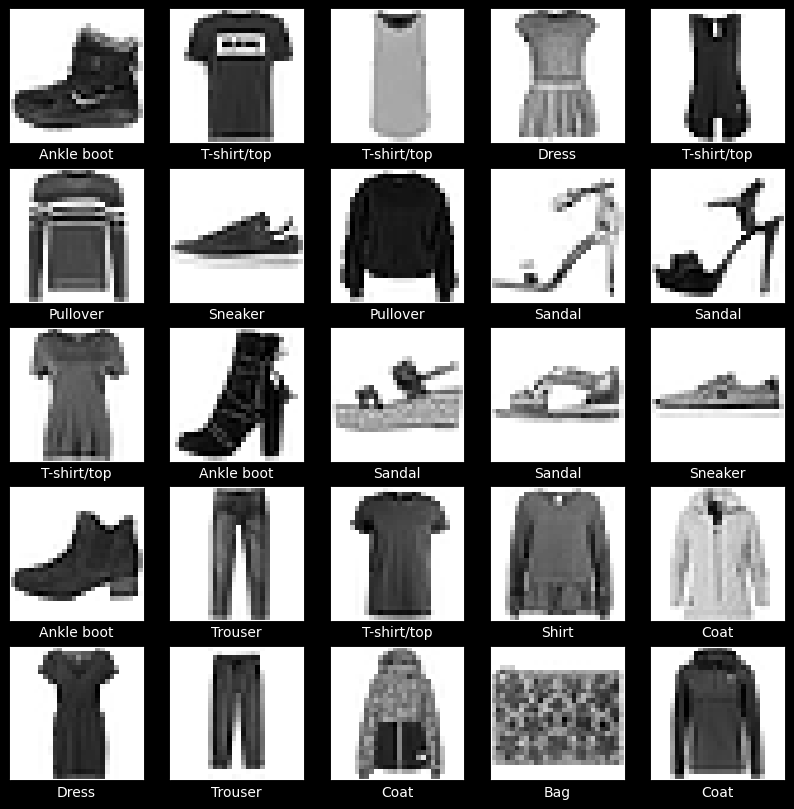

In [132]:
# BITNO: zapamtiti kako se radi ovo iscrtavanje
plt.figure(figsize = (10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1) # kreira mrezu podgrafika unutar figure, mreza ce imati 5 reda i 5 kolona, i+1 je indeks trenutnog podgrafika
    plt.xticks([]) # uklanja crtice duz x ose, s obzirom da radimo sa slicicama nisu nam potrebne
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap = plt.cm.binary) # prikazuje i-tu sliku, cmap postavlja mapu boja na crno belu
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [133]:
# kreiranje modela

# definisanje slojeva
# sloj (layer) -> osnovni termin i element koji se koristi za definisanje arhitekture mreze
# karakteristika slojeva -> svaki sloj vrsi neku transformaciju podataka sa ulaza i rezultat prosledjuje na izlaz

# imamo 3 vrste slojeva
# 1. tf.keras.layers.Flatten -> ravna prosledjeni oblik podataka, odnosno u ovom slucaju od matrice dimenzije (28, 28) dobijamo niz dimenzije 784, jer gusti (dense) slojevi nase mreze rade samo sa podacima koji se nalaze u nizu
  # ovaj sloj ne uci nista, ne podesava nikakve parametre itd, on samo menja oblik podataka
# 2. tf.keras.layers.Dense -> omogucava da definisemo koliko neurona zelimo da imamo unutar mreze
# 3. tf.keras.layers.Dropout -> omogucava borbu protiv preprilagodjavanja

# tf.keras.Sequential -> omogucava da izgradimo neuronsku mrezu na nacin koji smo zadali, odnosno to je objekat koji konstruisemo iz liste slojeva koje smo zadali

In [134]:
model = keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (28, 28)),
    # definisemo potpuno povezani sloj od 128 neurona sa relu aktivacijom
    tf.keras.layers.Dense(128, activation = 'relu'),
    # softmax aktivacija se koristi ISKLJUCIVO za izlazni sloj neuronske mreze kada radimo viseklasnu klasifikaciju
    # softmax pretvara sirove rezultate u distribuciju verovatnoca
    tf.keras.layers.Dense(10, activation = 'softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [135]:
# one hot encoding -> konvertuje labele (integer vrednosti) u binarni vektor gde je samo jedan element 1 (hot) a svi ostali su 0
# na primer: labela 9 se slika u vektor [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
# ovo je jako bitno kod viseklasne klasifikacije koje koriste softmax izlazni sloj (kako bi se poklapao oblik izlaza mreze i stvarnog resenja)
train_labels_cat = keras.utils.to_categorical(train_labels)
test_labels_cat = keras.utils.to_categorical(test_labels)

In [136]:
print(train_labels_cat)

[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [137]:
model.compile(optimizer = 'adam', loss = tf.keras.losses.CategoricalCrossentropy(), metrics = ['accuracy'])

In [138]:
# obucavanje modela
model.fit(train_images, train_labels_cat, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8280 - loss: 0.4898
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8652 - loss: 0.3745
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8786 - loss: 0.3326
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8856 - loss: 0.3104
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8920 - loss: 0.2929
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8979 - loss: 0.2777
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9008 - loss: 0.2647
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9046 - loss: 0.2541
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9084 - loss: 0.2438
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9109 - loss: 0.2364


In [139]:
# evaluacija tacnosti
test_loss, test_acc = model.evaluate(test_images, test_labels_cat, verbose = 2)
print(test_loss)
print(test_acc)

313/313 - 1s - 3ms/step - accuracy: 0.8791 - loss: 0.3448
0.3447825610637665
0.8791000247001648


In [140]:
# koriscenje modela
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [141]:
predictions[0]

array([4.65647901e-07, 1.80173227e-08, 1.33652065e-07, 1.25825272e-09,
       4.21621678e-07, 2.94440339e-04, 1.10244926e-07, 8.58310517e-03,
       4.70678742e-07, 9.91120756e-01], dtype=float32)

In [142]:
ix = np.argmax(predictions[0])
print(class_names[ix])
print(class_names[test_labels[0]]) # model je u pravu

Ankle boot
Ankle boot


In [151]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap = plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'white'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label], 100*np.max(predictions_array), class_names[true_label]), color = color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color = "#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

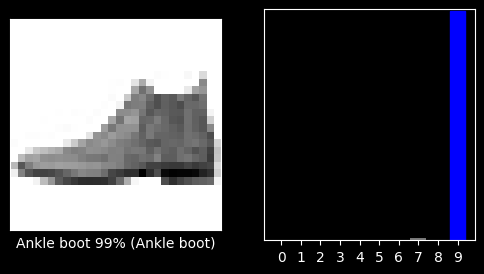

In [152]:
i = 0
plt.figure(figsize = (6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

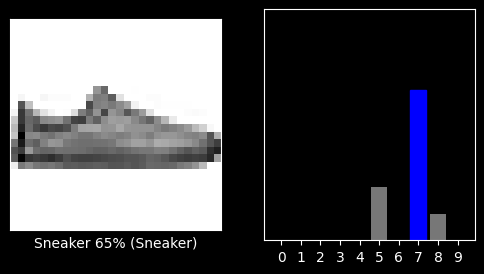

In [153]:
i = 12
plt.figure(figsize = (6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

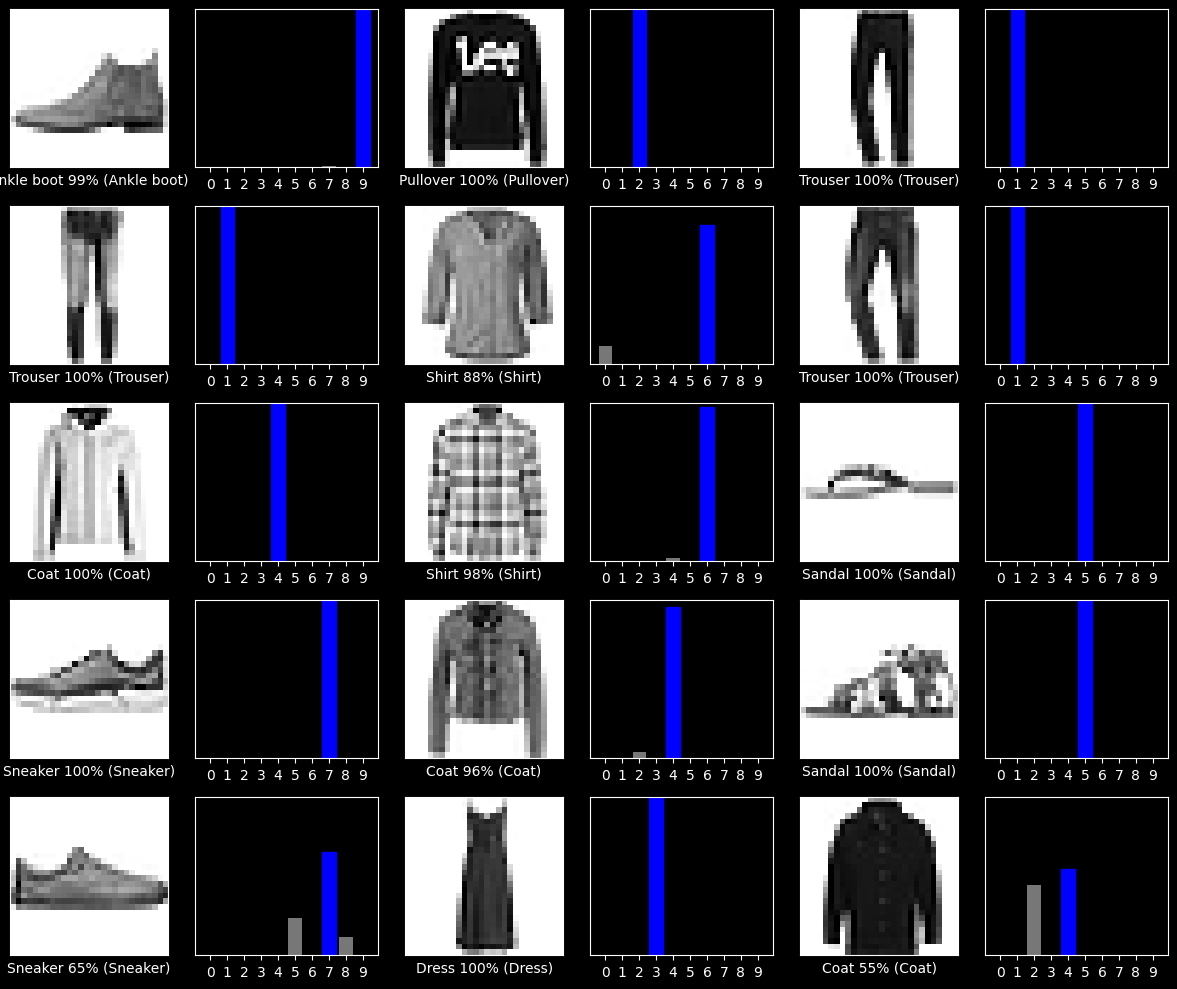

In [154]:
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize = (2*2*num_cols, 2*num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()